In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from pathlib import Path
from sklearn.linear_model import LinearRegression

# Set project paths
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data" / "cleaned"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
primary = pd.read_csv(DATA_DIR / "primary_gender_merged.csv")
secondary = pd.read_csv(DATA_DIR / "secondary_gender_merged.csv")
tertiary = pd.read_csv(DATA_DIR / "tertiary_gender_merged.csv")

In [3]:
datasets = {
    "Primary": primary,
    "Secondary": secondary,
    "Tertiary": tertiary
}

for name, df in datasets.items():
    print(f"\n{name} dataset")
    print(df.head())
    print(df.info())
    print(df.isna().sum())


Primary dataset
                  country_name country_code  year  male_enrollment  \
0  Africa Eastern and Southern          AFE  2000        83.367851   
1   Africa Western and Central          AFW  2000        89.540253   
2                   Arab World          ARB  2000        93.257462   
3                    Australia          AUS  2000       101.746597   
4          East Asia & Pacific          EAS  2000       110.146797   

   female_enrollment  
0          74.106873  
1          71.428177  
2          82.658501  
3         101.411880  
4         110.308182  
<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country_name       312 non-null    str    
 1   country_code       312 non-null    str    
 2   year               312 non-null    int64  
 3   male_enrollment    312 non-null    float64
 4   female_enrollment  312 non-null    flo

In [4]:
for df in [primary, secondary, tertiary]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["male_enrollment"] = pd.to_numeric(df["male_enrollment"], errors="coerce")
    df["female_enrollment"] = pd.to_numeric(df["female_enrollment"], errors="coerce")

In [5]:
for df in [primary, secondary, tertiary]:
    df["gender_gap"] = df["male_enrollment"] - df["female_enrollment"]

primary["level"] = "Primary"
secondary["level"] = "Secondary"
tertiary["level"] = "Tertiary"

In [15]:
con = sqlite3.connect(":memory:")

primary.to_sql("primary_table", con, index=False, if_exists="replace")
secondary.to_sql("secondary_table", con, index=False, if_exists="replace")
tertiary.to_sql("tertiary_table", con, index=False, if_exists="replace")

312

In [16]:
coverage_primary = pd.read_sql_query("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(male_enrollment) AS non_missing_male,
    COUNT(female_enrollment) AS non_missing_female
FROM primary_table
""", con)

coverage_secondary = pd.read_sql_query("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(male_enrollment) AS non_missing_male,
    COUNT(female_enrollment) AS non_missing_female
FROM secondary_table
""", con)

coverage_tertiary = pd.read_sql_query("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(male_enrollment) AS non_missing_male,
    COUNT(female_enrollment) AS non_missing_female
FROM tertiary_table
""", con)

print("Primary coverage")
display(coverage_primary)

print("Secondary coverage")
display(coverage_secondary)

print("Tertiary coverage")
display(coverage_tertiary)

Primary coverage


,total_rows,non_missing_male,non_missing_female
0,312,312,312


Secondary coverage


,total_rows,non_missing_male,non_missing_female
0,312,295,295


Tertiary coverage


,total_rows,non_missing_male,non_missing_female
0,312,291,291


In [17]:
summary_primary = pd.read_sql_query("""
SELECT
    AVG(male_enrollment) AS avg_male,
    AVG(female_enrollment) AS avg_female,
    AVG(gender_gap) AS avg_gap
FROM primary_table
""", con)

summary_secondary = pd.read_sql_query("""
SELECT
    AVG(male_enrollment) AS avg_male,
    AVG(female_enrollment) AS avg_female,
    AVG(gender_gap) AS avg_gap
FROM secondary_table
""", con)

summary_tertiary = pd.read_sql_query("""
SELECT
    AVG(male_enrollment) AS avg_male,
    AVG(female_enrollment) AS avg_female,
    AVG(gender_gap) AS avg_gap
FROM tertiary_table
""", con)

print("Primary summary")
display(summary_primary)

print("Secondary summary")
display(summary_secondary)

print("Tertiary summary")
display(summary_tertiary)

Primary summary


,avg_male,avg_female,avg_gap
0,101.452112,98.446556,3.005555


Secondary summary


,avg_male,avg_female,avg_gap
0,75.209767,72.987773,2.221994


Tertiary summary


,avg_male,avg_female,avg_gap
0,34.912865,41.565356,-6.65249


In [18]:
tertiary_region_summary = pd.read_sql_query("""
SELECT
    country_name,
    ROUND(AVG(male_enrollment), 2) AS avg_male,
    ROUND(AVG(female_enrollment), 2) AS avg_female,
    ROUND(AVG(gender_gap), 2) AS avg_gap
FROM tertiary_table
GROUP BY country_name
ORDER BY avg_gap DESC
""", con)

display(tertiary_region_summary)

,country_name,avg_male,avg_female,avg_gap
0,Low income,9.15,5.55,3.60
1,Africa Western and Central,9.81,6.24,3.57
2,South Asia,21.09,18.55,2.53
3,Lower middle income,18.47,16.82,1.65
4,Africa Eastern and Southern,7.67,6.21,1.45
5,Arab World,24.68,26.33,-1.65
6,East Asia & Pacific,34.22,37.29,-3.07
7,Upper middle income,34.86,40.19,-5.33
8,Latin America & Caribbean,37.49,48.47,-10.98
9,European Union,60.10,73.99,-13.89


In [19]:
def plot_gender_trends(df, title, filename):
    yearly = (
        df.groupby("year")[["male_enrollment", "female_enrollment"]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))
    plt.plot(yearly["year"], yearly["male_enrollment"], label="Male")
    plt.plot(yearly["year"], yearly["female_enrollment"], label="Female")
    plt.title(f"{title} Enrollment Over Time")
    plt.xlabel("Year")
    plt.ylabel("Gross Enrollment (%)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

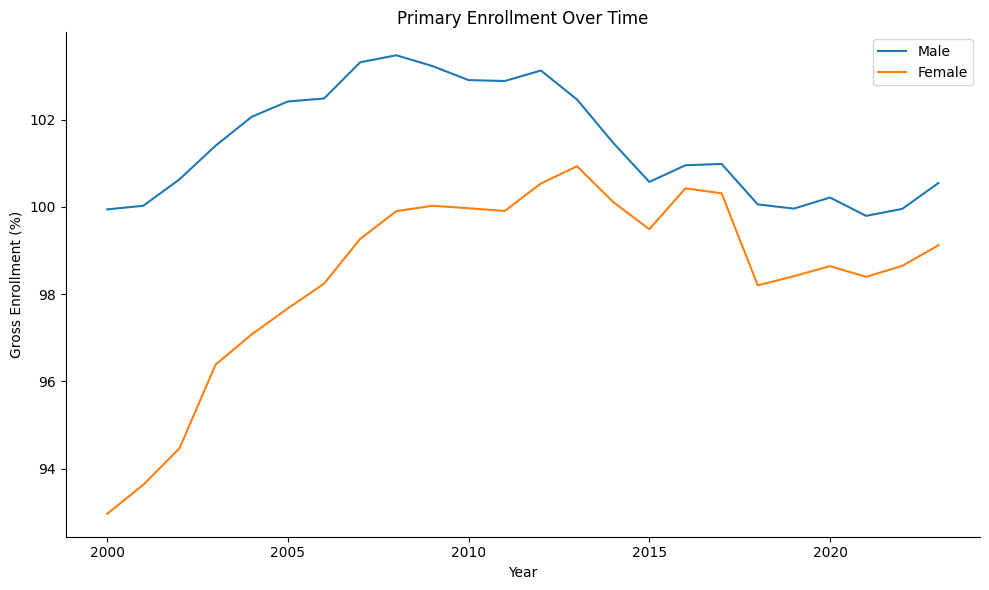

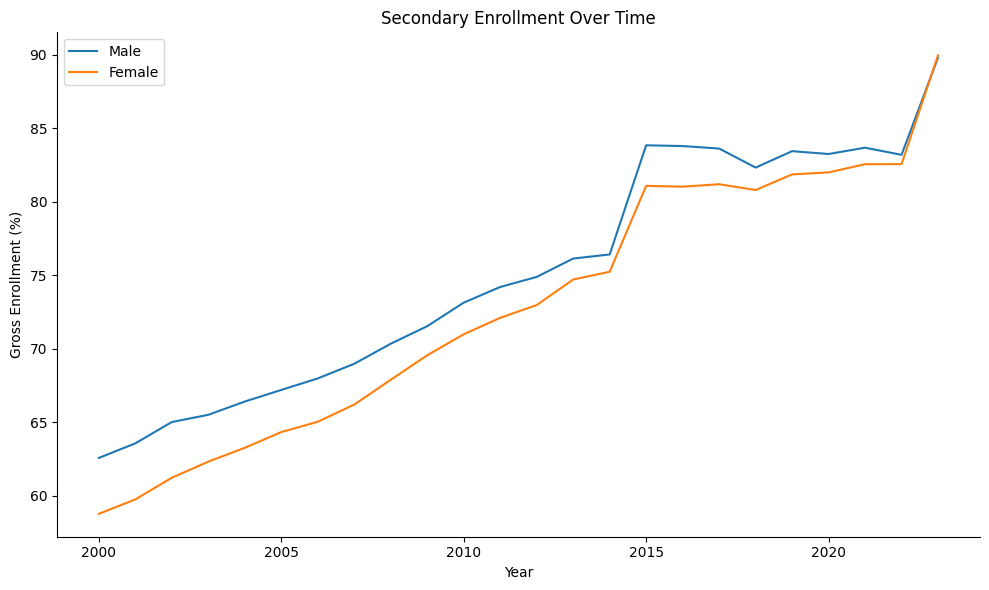

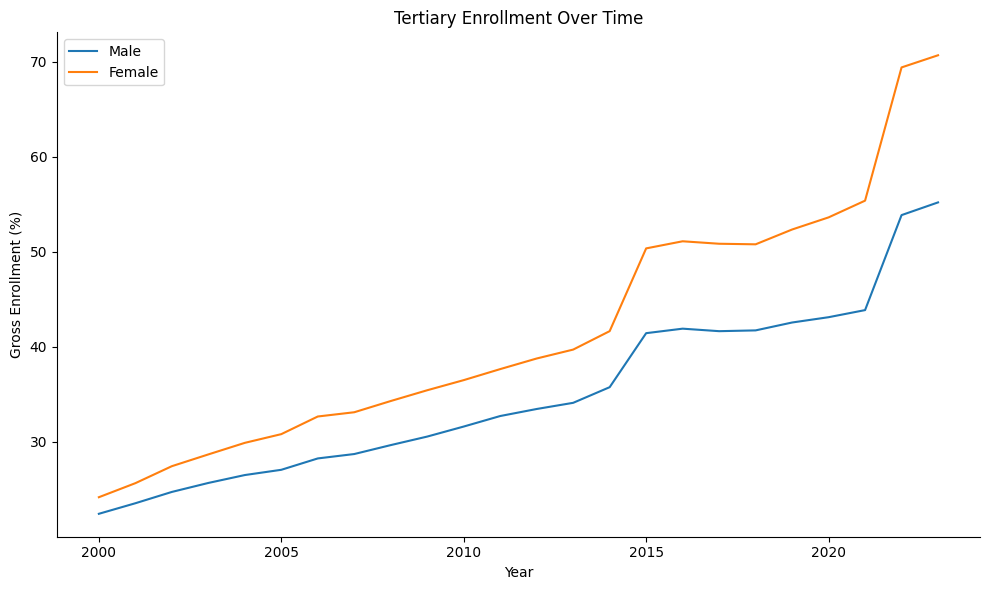

In [20]:
plot_gender_trends(primary, "Primary", "primary_gender_trends.png")
plot_gender_trends(secondary, "Secondary", "secondary_gender_trends.png")
plot_gender_trends(tertiary, "Tertiary", "tertiary_gender_trends.png")

In [21]:
def plot_gender_gap(df, title, filename):
    gap = (
        df.groupby("year")["gender_gap"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))
    plt.plot(gap["year"], gap["gender_gap"])
    plt.axhline(0, linestyle="--")
    plt.title(f"{title} Gender Gap Over Time (Male - Female)")
    plt.xlabel("Year")
    plt.ylabel("Gender Gap")
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

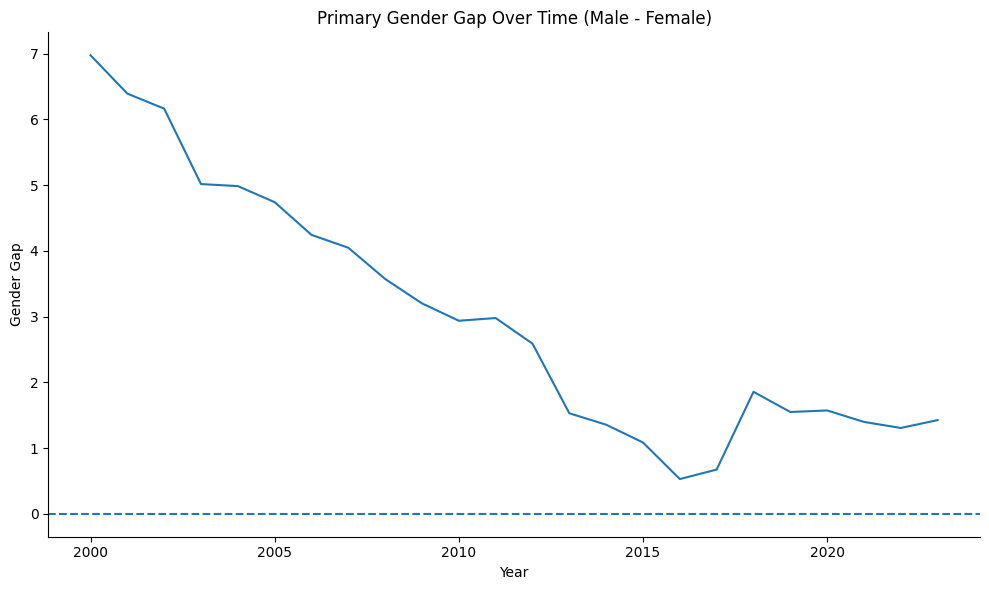

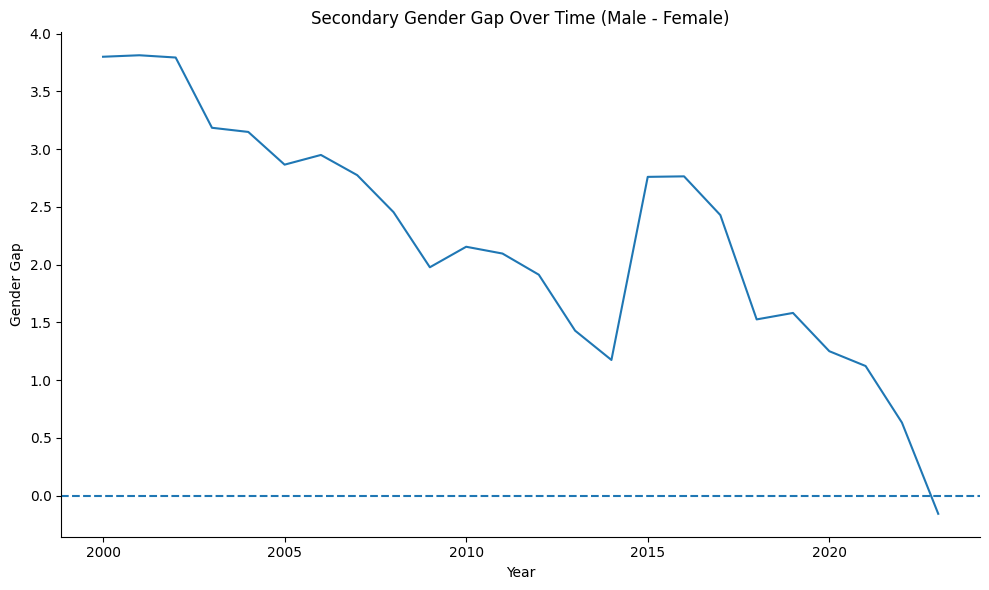

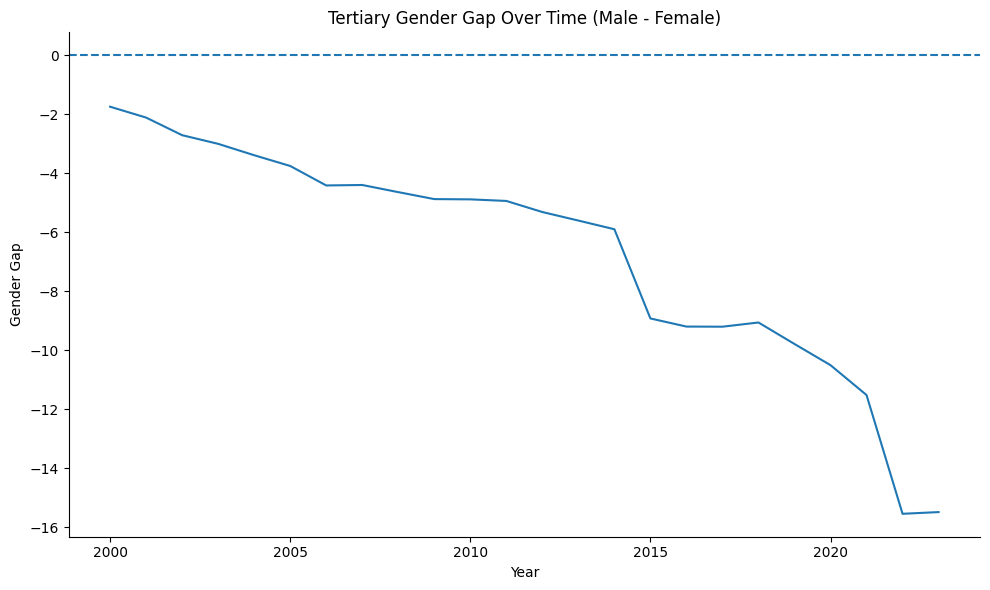

In [22]:
plot_gender_gap(primary, "Primary", "primary_gap_trend.png")
plot_gender_gap(secondary, "Secondary", "secondary_gap_trend.png")
plot_gender_gap(tertiary, "Tertiary", "tertiary_gap_trend.png")

In [23]:
combined = pd.concat([primary, secondary, tertiary], ignore_index=True)

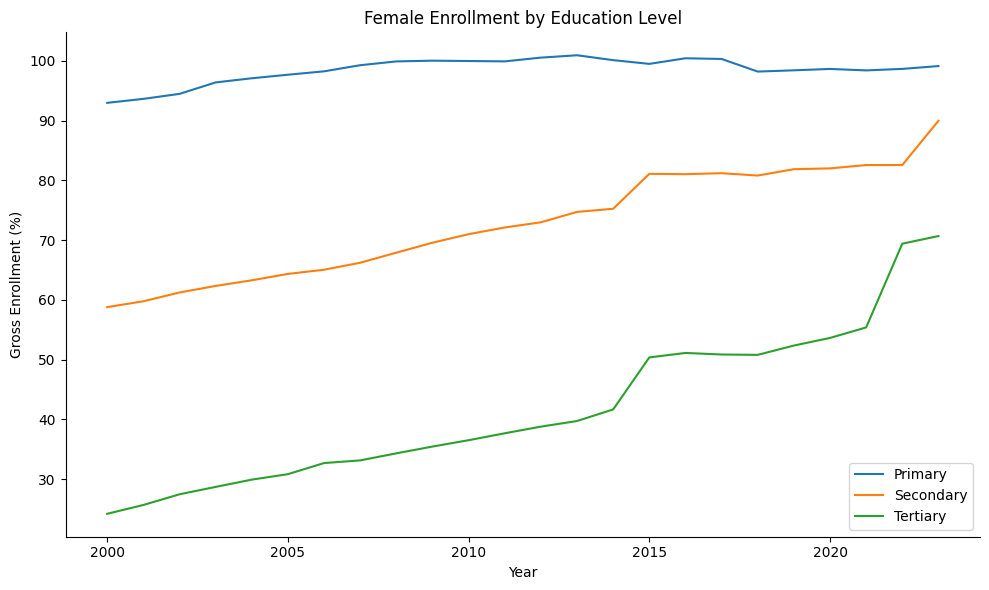

In [24]:
female_level = (
    combined.groupby(["year", "level"])["female_enrollment"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for level in female_level["level"].unique():
    subset = female_level[female_level["level"] == level]
    plt.plot(subset["year"], subset["female_enrollment"], label=level)

plt.title("Female Enrollment by Education Level")
plt.xlabel("Year")
plt.ylabel("Gross Enrollment (%)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "female_enrollment_by_level.png", dpi=300, bbox_inches="tight")
plt.show()

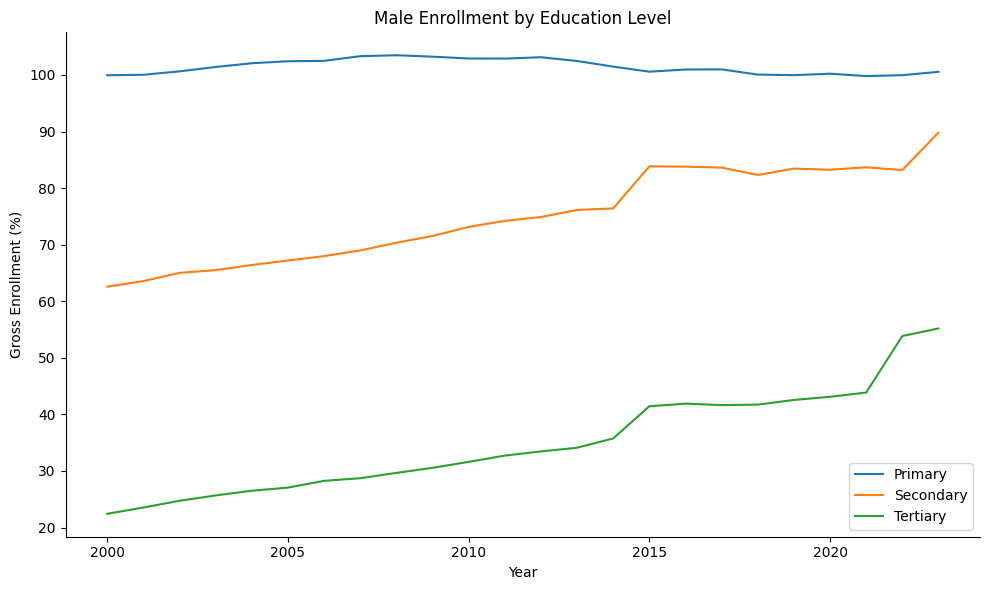

In [25]:
male_level = (
    combined.groupby(["year", "level"])["male_enrollment"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for level in male_level["level"].unique():
    subset = male_level[male_level["level"] == level]
    plt.plot(subset["year"], subset["male_enrollment"], label=level)

plt.title("Male Enrollment by Education Level")
plt.xlabel("Year")
plt.ylabel("Gross Enrollment (%)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "male_enrollment_by_level.png", dpi=300, bbox_inches="tight")
plt.show()

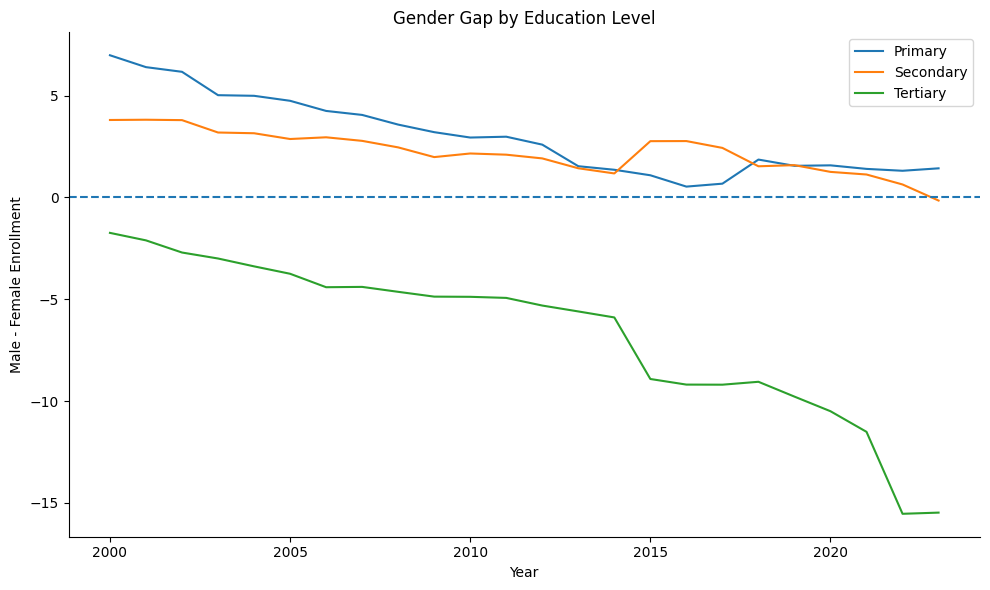

In [26]:
gap_level = (
    combined.groupby(["year", "level"])["gender_gap"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for level in gap_level["level"].unique():
    subset = gap_level[gap_level["level"] == level]
    plt.plot(subset["year"], subset["gender_gap"], label=level)

plt.axhline(0, linestyle="--")
plt.title("Gender Gap by Education Level")
plt.xlabel("Year")
plt.ylabel("Male - Female Enrollment")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "gender_gap_by_level.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
latest_year = combined["year"].max()
latest = combined[combined["year"] == latest_year].copy()

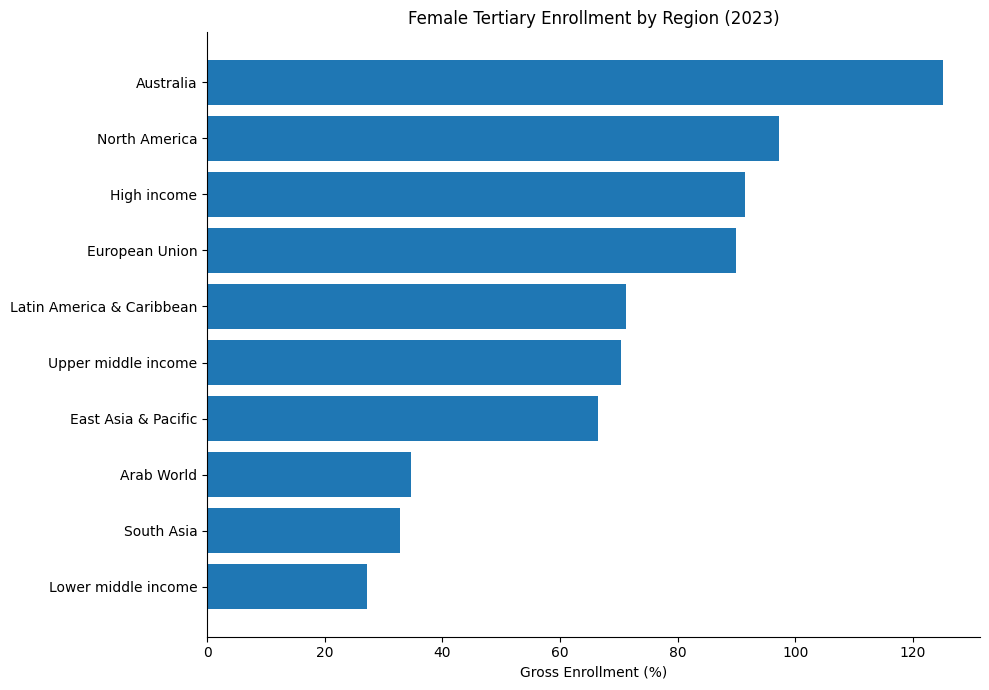

In [28]:
tertiary_latest_female = (
    latest[latest["level"] == "Tertiary"]
    .sort_values("female_enrollment")
)

plt.figure(figsize=(10, 7))
plt.barh(tertiary_latest_female["country_name"], tertiary_latest_female["female_enrollment"])
plt.title(f"Female Tertiary Enrollment by Region ({int(latest_year)})")
plt.xlabel("Gross Enrollment (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "female_tertiary_latest_region.png", dpi=300, bbox_inches="tight")
plt.show()

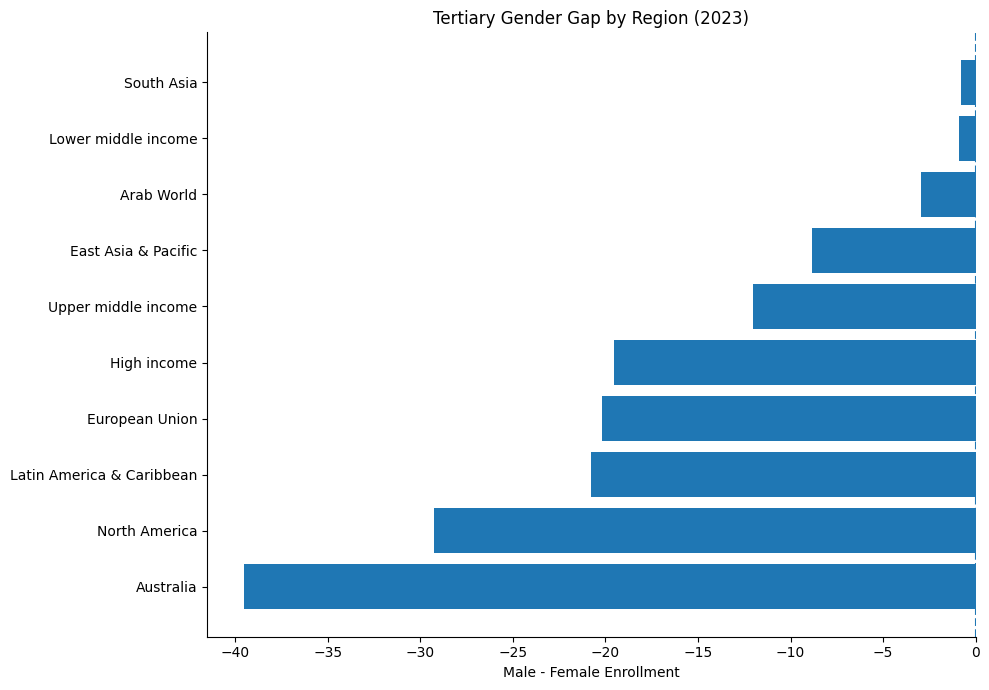

In [29]:
tertiary_latest_gap = (
    latest[latest["level"] == "Tertiary"]
    .sort_values("gender_gap")
)

plt.figure(figsize=(10, 7))
plt.barh(tertiary_latest_gap["country_name"], tertiary_latest_gap["gender_gap"])
plt.axvline(0, linestyle="--")
plt.title(f"Tertiary Gender Gap by Region ({int(latest_year)})")
plt.xlabel("Male - Female Enrollment")
plt.tight_layout()
plt.savefig(FIG_DIR / "tertiary_gap_latest_region.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
def run_trend_model(df, outcome, label):
    model_df = df.dropna(subset=["year", outcome]).copy()

    yearly = (
        model_df.groupby("year")[outcome]
        .mean()
        .reset_index()
    )

    X = yearly[["year"]]
    y = yearly[outcome]

    model = LinearRegression()
    model.fit(X, y)

    print(label)
    print("Slope:", round(model.coef_[0], 4))
    print("Intercept:", round(model.intercept_, 4))
    print("R^2:", round(model.score(X, y), 4))
    print()

In [32]:
run_trend_model(primary, "female_enrollment", "Primary female enrollment trend")
run_trend_model(secondary, "female_enrollment", "Secondary female enrollment trend")
run_trend_model(tertiary, "female_enrollment", "Tertiary female enrollment trend")

Primary female enrollment trend
Slope: 0.1831
Intercept: -269.7589
R^2: 0.357

Secondary female enrollment trend
Slope: 1.2492
Intercept: -2439.902
R^2: 0.9712

Tertiary female enrollment trend
Slope: 1.7628
Intercept: -3504.1905
R^2: 0.9216



In [33]:
run_trend_model(primary, "male_enrollment", "Primary male enrollment trend")
run_trend_model(secondary, "male_enrollment", "Secondary male enrollment trend")
run_trend_model(tertiary, "male_enrollment", "Tertiary male enrollment trend")

Primary male enrollment trend
Slope: -0.0669
Intercept: 236.0868
R^2: 0.1328

Secondary male enrollment trend
Slope: 1.1221
Intercept: -2182.0531
R^2: 0.9522

Tertiary male enrollment trend
Slope: 1.245
Intercept: -2469.4028
R^2: 0.9318

